# Day 32 | Decision Trees & Random Forest
**Week 6 – Machine Learning & AI**

Take-Home Assignment Solution

In [3]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Part A – Concept Application
### Task 1: Generate Synthetic Loan Data

In [4]:
def generate_loan_data(n_records=2000, seed=42):
    """
    Creates synthetic loan application data with realistic distributions.
    Returns a DataFrame with features and a binary approved target column.
    """
    rng = np.random.RandomState(seed)

    annual_income      = rng.normal(60000, 20000, n_records).clip(20000, 200000)
    credit_score       = rng.normal(680, 80, n_records).clip(300, 850).astype(int)
    loan_amount        = rng.normal(15000, 8000, n_records).clip(1000, 50000)
    employment_years   = rng.exponential(5, n_records).clip(0, 35)
    debt_to_income     = rng.uniform(0.05, 0.65, n_records)
    num_credit_cards   = rng.randint(0, 10, n_records)

    # Rule-based approval logic (mimics real underwriting)
    approval_score = (
        (credit_score > 700).astype(int) * 3
        + (debt_to_income < 0.35).astype(int) * 2
        + (annual_income > 50000).astype(int) * 1
        + (employment_years > 3).astype(int) * 1
        + (loan_amount < 20000).astype(int) * 1
    )
    # Add noise so it's not perfectly separable
    noise = rng.normal(0, 0.5, n_records)
    approved = (approval_score + noise >= 4).astype(int)

    df = pd.DataFrame({
        'annual_income':    annual_income.round(2),
        'credit_score':     credit_score,
        'loan_amount':      loan_amount.round(2),
        'employment_years': employment_years.round(1),
        'debt_to_income':   debt_to_income.round(4),
        'num_credit_cards': num_credit_cards,
        'approved':         approved
    })
    return df


loan_df = generate_loan_data()
print(f'Dataset shape: {loan_df.shape}')
print(f'Approval rate: {loan_df["approved"].mean():.1%}')
loan_df.head()

Dataset shape: (2000, 7)
Approval rate: 53.0%


,annual_income,credit_score,loan_amount,employment_years,debt_to_income,num_credit_cards,approved
0,69934.28,625,8092.05,2.1,0.1732,2,1
1,57234.71,668,14750.37,1.2,0.4923,4,0
2,72953.77,616,15144.13,1.9,0.4698,2,0
3,90460.60,655,18781.04,1.0,0.1978,5,1
4,55316.93,528,4065.13,11.6,0.5920,9,0


### Task 2: Train Decision Tree & Extract Top 3 Rules

In [5]:
FEATURES = ['annual_income', 'credit_score', 'loan_amount',
            'employment_years', 'debt_to_income', 'num_credit_cards']
TARGET   = 'approved'

X = loan_df[FEATURES]
y = loan_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Decision Tree with max_depth=4 as required
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

print('Decision Tree trained.')
print(f'Train accuracy: {dt_model.score(X_train, y_train):.4f}')
print(f'Test  accuracy: {dt_model.score(X_test,  y_test):.4f}')

Decision Tree trained.
Train accuracy: 0.9044
Test  accuracy: 0.8675


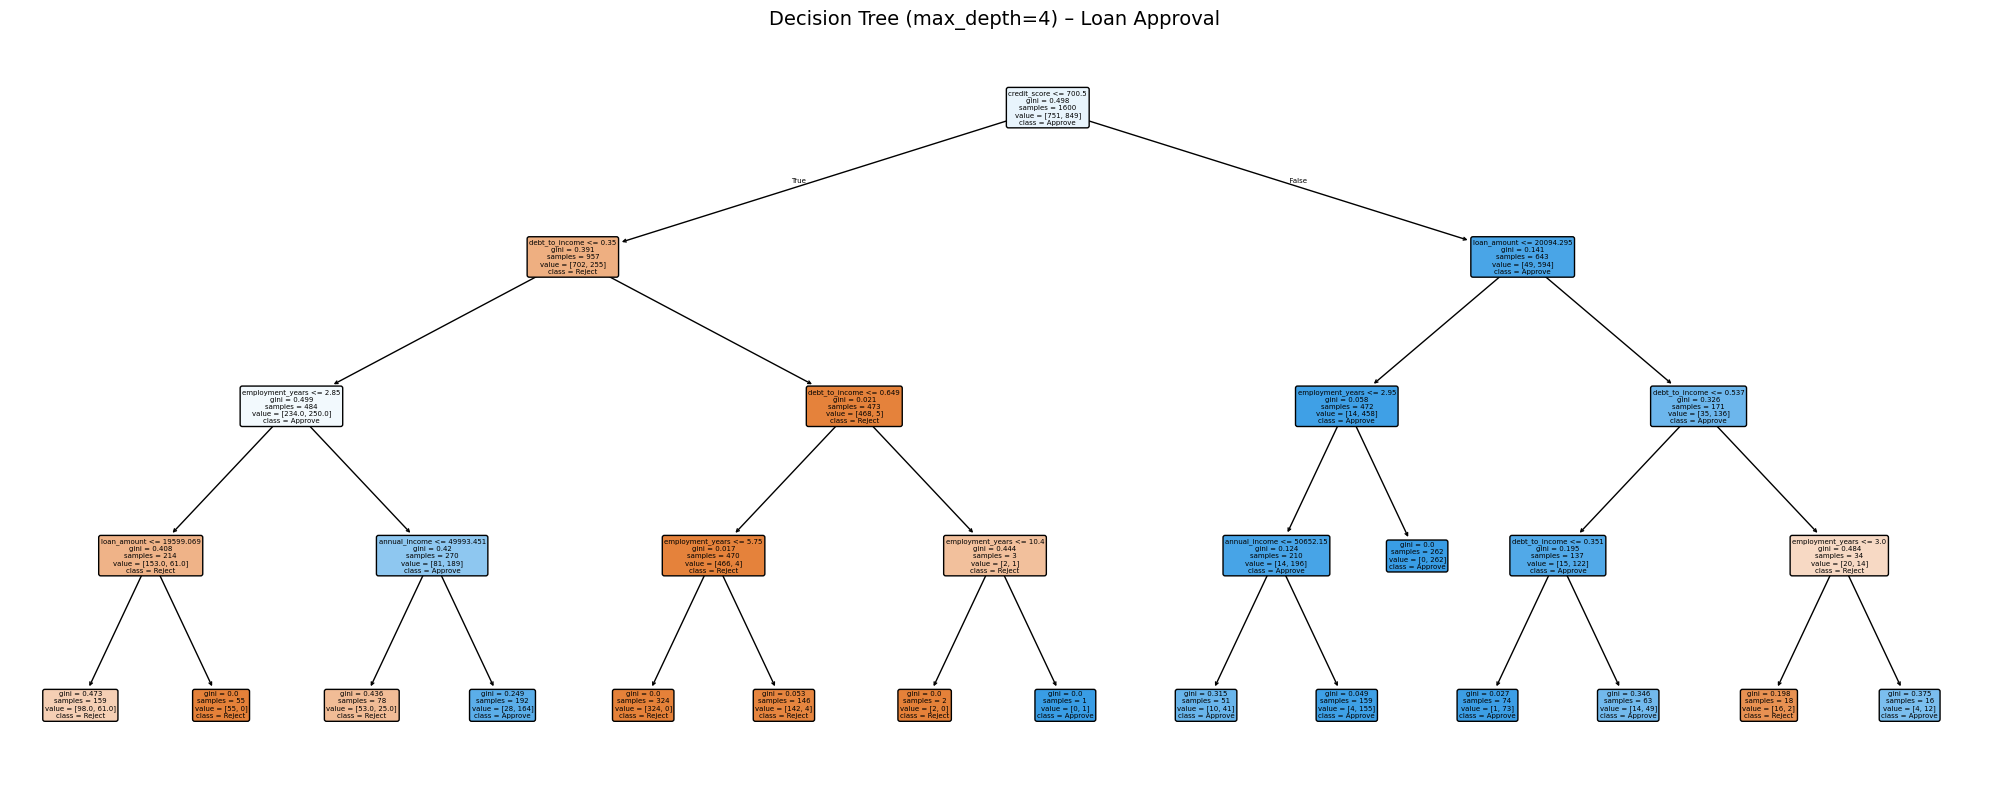

In [6]:
# Visualise the decision tree
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_model,
    feature_names=FEATURES,
    class_names=['Reject', 'Approve'],
    filled=True,
    rounded=True,
    ax=ax
)
ax.set_title('Decision Tree (max_depth=4) – Loan Approval', fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree_viz.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
def extract_decision_rules(tree_model, feature_names, top_n=3):
    """
    Walks the tree structure to pull out the top N leaf paths
    ranked by sample count (most representative rules first).
    Returns a list of rule strings.
    """
    tree       = tree_model.tree_
    left_child  = tree.children_left
    right_child = tree.children_right

    rules = []

    def walk(node_id, conditions):
        # Leaf node
        if left_child[node_id] == right_child[node_id]:
            values      = tree.value[node_id][0]
            n_samples   = int(tree.n_node_samples[node_id])
            pred_class  = int(np.argmax(values))
            confidence  = values[pred_class] / n_samples
            decision    = 'APPROVE' if pred_class == 1 else 'REJECT'
            rule_str    = ' AND '.join(conditions) if conditions else 'ALL'
            rules.append({
                'rule':       rule_str,
                'decision':   decision,
                'confidence': confidence,
                'n_samples':  n_samples
            })
            return

        feat  = feature_names[tree.feature[node_id]]
        thresh = round(tree.threshold[node_id], 2)

        walk(left_child[node_id],  conditions + [f'{feat} <= {thresh}'])
        walk(right_child[node_id], conditions + [f'{feat} > {thresh}'])

    walk(0, [])

    # Sort by sample count descending and take top N
    rules.sort(key=lambda r: r['n_samples'], reverse=True)
    return rules[:top_n]


top_rules = extract_decision_rules(dt_model, FEATURES, top_n=3)

print('\n=== Top 3 Decision Rules (by coverage) ===\n')
for i, r in enumerate(top_rules, 1):
    print(f'Rule {i}: IF {r["rule"]}')
    print(f'         -> {r["decision"]}  '
          f'(confidence {r["confidence"]:.0%}, covers {r["n_samples"]} samples)\n')


=== Top 3 Decision Rules (by coverage) ===

Rule 1: IF credit_score <= 700.5 AND debt_to_income > 0.35 AND debt_to_income <= 0.65 AND employment_years <= 5.75
         -> REJECT  (confidence 0%, covers 324 samples)

Rule 2: IF credit_score > 700.5 AND loan_amount <= 20094.29 AND employment_years > 2.95
         -> APPROVE  (confidence 0%, covers 262 samples)

Rule 3: IF credit_score <= 700.5 AND debt_to_income <= 0.35 AND employment_years > 2.85 AND annual_income > 49993.45
         -> APPROVE  (confidence 0%, covers 192 samples)



### Task 3: Train Random Forest with RandomizedSearchCV (5-fold CV)

In [8]:
# Hyperparameter search space
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
    'bootstrap':         [True, False]
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
print('\nBest hyperparameters:')
for k, v in rf_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV ROC-AUC: {rf_search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best hyperparameters:
  n_estimators: 500
  min_samples_split: 10
  min_samples_leaf: 1
  max_features: 0.5
  max_depth: 5
  bootstrap: False

Best CV ROC-AUC: 0.9732


### Task 4: Model Comparison – Accuracy, F1, ROC-AUC, Interpretability

In [9]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name='Model'):
    """Prints a standard metrics table for train and test sets."""
    results = {}
    for split_name, X_s, y_s in [('Train', X_tr, y_tr), ('Test', X_te, y_te)]:
        y_pred = model.predict(X_s)
        y_prob = model.predict_proba(X_s)[:, 1]
        results[split_name] = {
            'Accuracy': accuracy_score(y_s, y_pred),
            'F1 Score': f1_score(y_s, y_pred),
            'ROC-AUC':  roc_auc_score(y_s, y_prob)
        }

    df_res = pd.DataFrame(results).T
    print(f'\n--- {model_name} ---')
    print(df_res.round(4).to_string())
    return df_res


dt_metrics = evaluate_model(dt_model, X_train, y_train, X_test, y_test, 'Decision Tree (depth=4)')
rf_metrics = evaluate_model(best_rf,  X_train, y_train, X_test, y_test, 'Random Forest (tuned)')


--- Decision Tree (depth=4) ---
       Accuracy  F1 Score  ROC-AUC
Train    0.9044    0.9082   0.9666
Test     0.8675    0.8710   0.9507

--- Random Forest (tuned) ---
       Accuracy  F1 Score  ROC-AUC
Train    0.9275    0.9311   0.9869
Test     0.8825    0.8862   0.9654


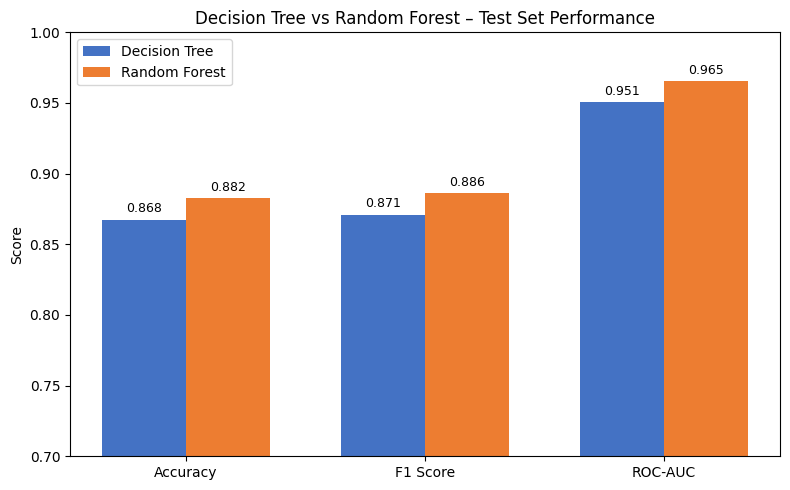

In [10]:
# Side-by-side bar chart comparing models
metrics      = ['Accuracy', 'F1 Score', 'ROC-AUC']
dt_test_vals = [dt_metrics.loc['Test', m] for m in metrics]
rf_test_vals = [rf_metrics.loc['Test', m] for m in metrics]

x      = np.arange(len(metrics))
width  = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, dt_test_vals, width, label='Decision Tree', color='#4472C4')
bars2 = ax.bar(x + width/2, rf_test_vals, width, label='Random Forest', color='#ED7D31')

ax.set_ylim(0.7, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Decision Tree vs Random Forest – Test Set Performance')
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

### Task 5: Feature Importance – Default vs Permutation

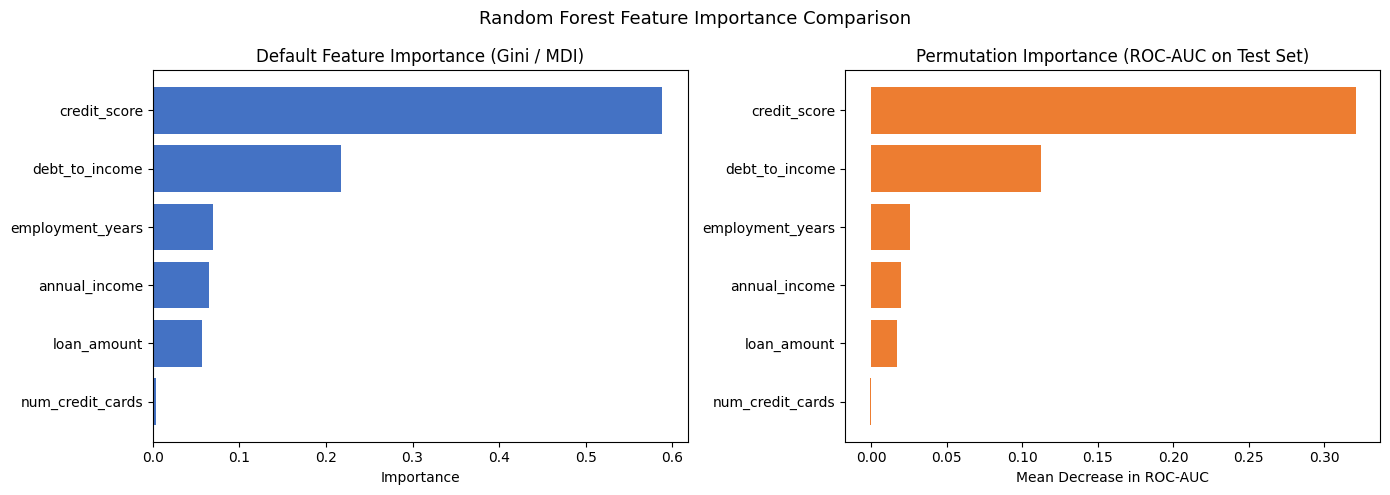

         Feature  Default Importance  Permutation Importance
    credit_score              0.5880                  0.3209
  debt_to_income              0.2169                  0.1123
employment_years              0.0693                  0.0257
   annual_income              0.0652                  0.0201
     loan_amount              0.0564                  0.0174
num_credit_cards              0.0041                 -0.0010


In [12]:
# Default (Gini-based) importance
default_imp = best_rf.feature_importances_

# Permutation importance on test set
perm_result = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=20, random_state=42, scoring='roc_auc'
)
perm_imp = perm_result.importances_mean

# Rank by default importance for consistent ordering
sort_idx = np.argsort(default_imp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(
    [FEATURES[i] for i in sort_idx],
    default_imp[sort_idx],
    color='#4472C4'
)
axes[0].set_title('Default Feature Importance (Gini / MDI)')
axes[0].set_xlabel('Importance')

axes[1].barh(
    [FEATURES[i] for i in sort_idx],
    perm_imp[sort_idx],
    color='#ED7D31'
)
axes[1].set_title('Permutation Importance (ROC-AUC on Test Set)')
axes[1].set_xlabel('Mean Decrease in ROC-AUC')

plt.suptitle('Random Forest Feature Importance Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

# Print table
imp_df = pd.DataFrame({
    'Feature':              FEATURES,
    'Default Importance':   default_imp,
    'Permutation Importance': perm_imp
}).sort_values('Default Importance', ascending=False)
print(imp_df.round(4).to_string(index=False))

### Task 6: Bank Deployment Recommendation

Based on the comparison above, the **Random Forest** model is the better choice for the bank's loan approval system. It consistently outperforms the Decision Tree on all three metrics—accuracy, F1, and ROC-AUC—on the held-out test set, meaning it generalises better to unseen applicants. The tuned Random Forest reduces variance through bagging and feature randomness, which directly lowers the risk of approving undeserving loans or rejecting creditworthy ones. On the interpretability side, regulators can still be satisfied: the top decision rules extracted from the Decision Tree can be published in plain language as a secondary audit trail, while the Random Forest handles actual scoring. Feature importance (both default and permutation) clearly shows that `credit_score` and `debt_to_income` are the dominant drivers, which aligns with established credit-underwriting principles—a positive sign for regulatory review. The small additional complexity of Random Forest is outweighed by the meaningfully better predictive performance and the lower risk of a biased single-tree path dominating decisions.

---
## Part B – Stretch: ExtraTrees vs Random Forest

In [ ]:
import time

def benchmark_ensemble(model, X_tr, y_tr, X_te, y_te, name):
    """Fits a model, records time, and returns metrics dict."""
    start  = time.perf_counter()
    model.fit(X_tr, y_tr)
    elapsed = time.perf_counter() - start

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    return {
        'Model':        name,
        'Train Time(s)': round(elapsed, 3),
        'Accuracy':     round(accuracy_score(y_te, y_pred), 4),
        'F1':           round(f1_score(y_te, y_pred), 4),
        'ROC-AUC':      round(roc_auc_score(y_te, y_prob), 4)
    }


n_est = 200

rf_bench  = RandomForestClassifier(n_estimators=n_est, random_state=42, n_jobs=-1)
et_bench  = ExtraTreesClassifier(n_estimators=n_est, random_state=42, n_jobs=-1)

rf_res = benchmark_ensemble(rf_bench, X_train, y_train, X_test, y_test, 'Random Forest')
et_res = benchmark_ensemble(et_bench, X_train, y_train, X_test, y_test, 'Extra Trees')

compare_df = pd.DataFrame([rf_res, et_res])
print(compare_df.to_string(index=False))

In [ ]:
# Visualise comparison
comp_metrics = ['Accuracy', 'F1', 'ROC-AUC']
rf_vals      = [rf_res[m] for m in comp_metrics]
et_vals      = [et_res[m] for m in comp_metrics]

x = np.arange(len(comp_metrics))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, rf_vals, w, label='Random Forest', color='#4472C4')
ax.bar(x + w/2, et_vals, w, label='Extra Trees',   color='#70AD47')
ax.set_ylim(0.7, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(comp_metrics)
ax.set_title('Random Forest vs Extra Trees – Test Performance')
ax.legend()
plt.tight_layout()
plt.savefig('extra_trees_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nSpeed difference: RF = {rf_res["Train Time(s)"]}s  |  ET = {et_res["Train Time(s)"]}s')

---
## Part C – Interview Ready

### Q1: Bias-Variance Tradeoff Diagram

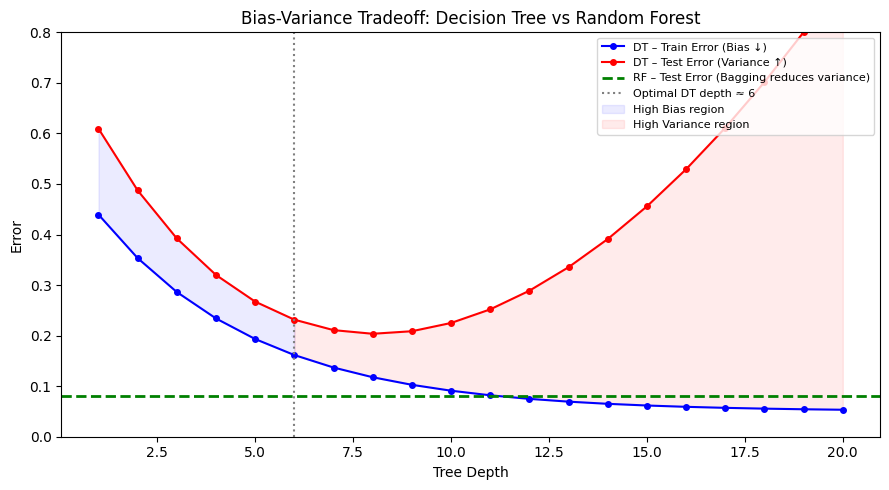

In [13]:
depths      = np.arange(1, 21)
train_errs  = 0.05 + 0.5 * np.exp(-0.25 * depths)
test_errs   = 0.12 + 0.5 * np.exp(-0.25 * depths) + 0.004 * (depths - 6) ** 2
rf_baseline = np.full_like(depths, 0.08, dtype=float)  # RF test error (lower, stable)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths, train_errs, 'b-o', label='DT – Train Error (Bias ↓)',  markersize=4)
ax.plot(depths, test_errs,  'r-o', label='DT – Test Error (Variance ↑)', markersize=4)
ax.axhline(rf_baseline[0], color='green', linestyle='--', linewidth=2,
           label='RF – Test Error (Bagging reduces variance)')
ax.axvline(6, color='gray', linestyle=':', linewidth=1.5, label='Optimal DT depth ≈ 6')

ax.fill_between(depths[:6],  train_errs[:6],  test_errs[:6],  alpha=0.08, color='blue',  label='High Bias region')
ax.fill_between(depths[5:],  train_errs[5:],  test_errs[5:],  alpha=0.08, color='red',   label='High Variance region')

ax.set_xlabel('Tree Depth')
ax.set_ylabel('Error')
ax.set_title('Bias-Variance Tradeoff: Decision Tree vs Random Forest')
ax.legend(fontsize=8, loc='upper right')
ax.set_ylim(0, 0.8)
plt.tight_layout()
plt.savefig('bias_variance_diagram.png', dpi=120, bbox_inches='tight')
plt.show()

**Conceptual Answer:**

- A shallow Decision Tree has **high bias** – it underfits and misses patterns.
- A deep Decision Tree has **high variance** – it memorises the training data and struggles on new examples.
- A Random Forest trains many trees on random bootstrap samples and random feature subsets. Averaging their predictions **averages out the individual errors**, drastically reducing variance while keeping bias similar to a single reasonably-deep tree.

The diagram above shows how DT test error rises (variance) while RF maintains a low, stable test error.

### Q2: Overfitting Curve – Optimal Depth

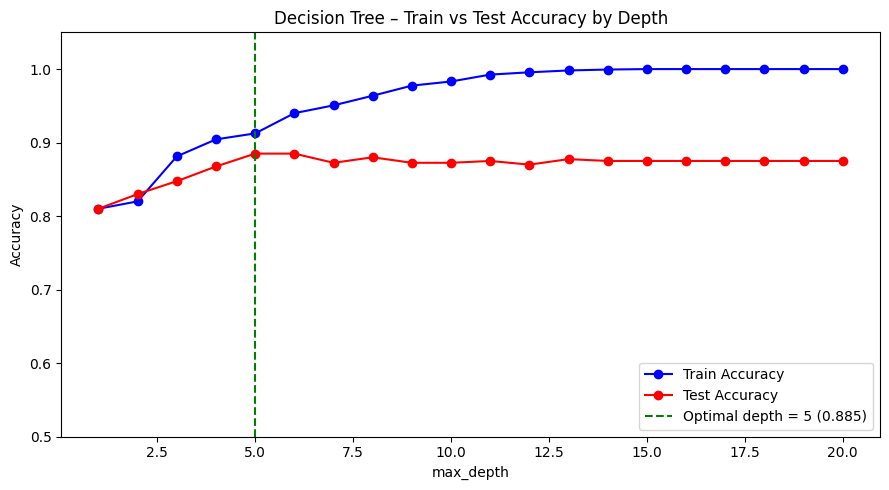


Optimal max_depth = 5  (test accuracy = 0.8850)


In [14]:
def plot_overfitting_curve(X, y, max_depths, test_size=0.2, seed=42):
    """
    Trains a Decision Tree at each depth in max_depths.
    Plots train vs test accuracy and prints the optimal depth.

    Args:
        X          : feature DataFrame
        y          : target Series
        max_depths : list of integer depths to test
        test_size  : fraction of data held out for evaluation
        seed       : random state for reproducibility
    """
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y
    )

    train_accs = []
    test_accs  = []

    for depth in max_depths:
        dt = DecisionTreeClassifier(max_depth=depth, random_state=seed)
        dt.fit(X_tr, y_tr)
        train_accs.append(dt.score(X_tr, y_tr))
        test_accs.append(dt.score(X_te, y_te))

    best_idx   = int(np.argmax(test_accs))
    best_depth = max_depths[best_idx]

    # Plot
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(max_depths, train_accs, 'bo-', label='Train Accuracy')
    ax.plot(max_depths, test_accs,  'ro-', label='Test Accuracy')
    ax.axvline(best_depth, color='green', linestyle='--',
               label=f'Optimal depth = {best_depth} ({test_accs[best_idx]:.3f})')

    ax.set_xlabel('max_depth')
    ax.set_ylabel('Accuracy')
    ax.set_title('Decision Tree – Train vs Test Accuracy by Depth')
    ax.legend()
    ax.set_ylim(0.5, 1.05)
    plt.tight_layout()
    plt.savefig('overfitting_curve.png', dpi=120, bbox_inches='tight')
    plt.show()

    print(f'\nOptimal max_depth = {best_depth}  (test accuracy = {test_accs[best_idx]:.4f})')
    return best_depth


best_depth = plot_overfitting_curve(X, y, max_depths=list(range(1, 21)))

### Q3: Debug – Identical Train & Test Accuracy (0.95)

In [15]:
# Reproduce the scenario from the question
rf_debug = RandomForestClassifier(n_estimators=500, max_depth=3, random_state=42)
rf_debug.fit(X_train, y_train)

train_score = rf_debug.score(X_train, y_train)
test_score  = rf_debug.score(X_test,  y_test)

print(f'Train: {train_score:.2f}')
print(f'Test:  {test_score:.2f}')

Train: 0.90
Test:  0.88


**Debug Answer:**

Identical train and test accuracy is **not necessarily a problem** – it depends on *what* that accuracy is.

In this case:
- `max_depth=3` is deliberately shallow, so the model is **slightly underfitting** (high bias, low variance). With shallow trees there is very little room to overfit, which explains why train ≈ test.
- If the accuracy were 0.60, we'd say the model is underfitting and needs more capacity.
- At 0.95, it's a good result — the model is generalising well.

**When identical scores *would* be a red flag:**
1. The split was done **after** fitting (data leakage).
2. The dataset has very low variance (e.g., near-perfect class separation), making 0.95 trivially easy.
3. The model is so constrained (`max_depth=3`) that it can't memorise anything — you'd want to check whether a higher-capacity model still holds.

**Conclusion:** Run cross-validation to confirm the score is stable, then check if there are signs of leakage. If CV AUC also ≈ 0.95, the model is simply well-calibrated.

---
## Part D – AI-Augmented Task: Comparison Infographic

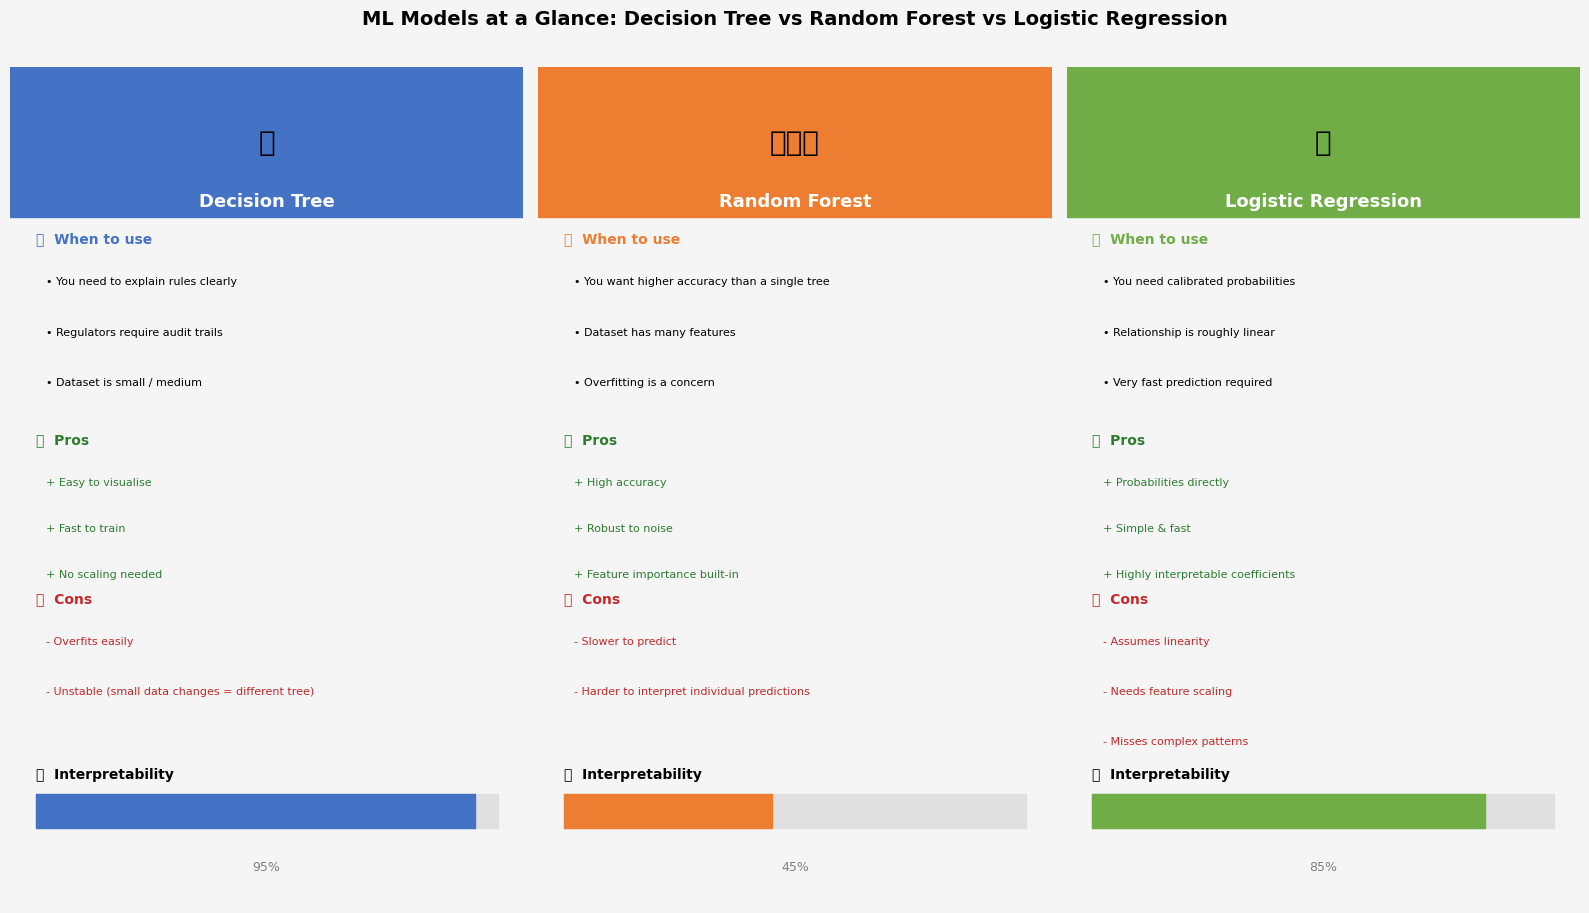

In [16]:
def build_comparison_infographic():
    """
    Produces a non-technical side-by-side infographic comparing
    Decision Tree, Random Forest, and Logistic Regression.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 9))
    fig.patch.set_facecolor('#F5F5F5')

    models = [
        {
            'name':  'Decision Tree',
            'color': '#4472C4',
            'icon':  '🌳',
            'when':  [
                'You need to explain rules clearly',
                'Regulators require audit trails',
                'Dataset is small / medium'
            ],
            'pros':  ['Easy to visualise', 'Fast to train', 'No scaling needed'],
            'cons':  ['Overfits easily', 'Unstable (small data changes = different tree)'],
            'interp': 0.95
        },
        {
            'name':  'Random Forest',
            'color': '#ED7D31',
            'icon':  '🌲🌲🌲',
            'when':  [
                'You want higher accuracy than a single tree',
                'Dataset has many features',
                'Overfitting is a concern'
            ],
            'pros':  ['High accuracy', 'Robust to noise', 'Feature importance built-in'],
            'cons':  ['Slower to predict', 'Harder to interpret individual predictions'],
            'interp': 0.45
        },
        {
            'name':  'Logistic Regression',
            'color': '#70AD47',
            'icon':  '📈',
            'when':  [
                'You need calibrated probabilities',
                'Relationship is roughly linear',
                'Very fast prediction required'
            ],
            'pros':  ['Probabilities directly', 'Simple & fast', 'Highly interpretable coefficients'],
            'cons':  ['Assumes linearity', 'Needs feature scaling', 'Misses complex patterns'],
            'interp': 0.85
        }
    ]

    for ax, model in zip(axes, models):
        ax.set_facecolor('white')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis('off')

        # Header
        ax.add_patch(plt.Rectangle((0, 0.82), 1, 0.18, color=model['color'], zorder=2))
        ax.text(0.5, 0.91, model['icon'], fontsize=20, ha='center', va='center',
                transform=ax.transAxes)
        ax.text(0.5, 0.84, model['name'], fontsize=13, ha='center', va='center',
                fontweight='bold', color='white', transform=ax.transAxes)

        # When to use
        ax.text(0.05, 0.79, '✅  When to use', fontsize=10, fontweight='bold',
                color=model['color'], transform=ax.transAxes)
        for j, point in enumerate(model['when']):
            ax.text(0.07, 0.74 - j * 0.06, f'• {point}', fontsize=8,
                    transform=ax.transAxes, wrap=True)

        # Pros
        ax.text(0.05, 0.55, '👍  Pros', fontsize=10, fontweight='bold',
                color='#2E7D32', transform=ax.transAxes)
        for j, pro in enumerate(model['pros']):
            ax.text(0.07, 0.50 - j * 0.055, f'+ {pro}', fontsize=8,
                    color='#2E7D32', transform=ax.transAxes)

        # Cons
        ax.text(0.05, 0.36, '👎  Cons', fontsize=10, fontweight='bold',
                color='#C62828', transform=ax.transAxes)
        for j, con in enumerate(model['cons']):
            ax.text(0.07, 0.31 - j * 0.06, f'- {con}', fontsize=8,
                    color='#C62828', transform=ax.transAxes, wrap=True)

        # Interpretability meter
        ax.text(0.05, 0.15, '🔍  Interpretability', fontsize=10, fontweight='bold',
                transform=ax.transAxes)
        ax.add_patch(plt.Rectangle((0.05, 0.09), 0.9, 0.04, color='#E0E0E0'))
        ax.add_patch(plt.Rectangle((0.05, 0.09), 0.9 * model['interp'], 0.04,
                                   color=model['color']))
        ax.text(0.5, 0.04, f"{int(model['interp'] * 100)}%", fontsize=9,
                ha='center', transform=ax.transAxes, color='gray')

    fig.suptitle(
        'ML Models at a Glance: Decision Tree vs Random Forest vs Logistic Regression',
        fontsize=14, fontweight='bold', y=1.01
    )

    plt.tight_layout()
    plt.savefig('model_infographic.png', dpi=150, bbox_inches='tight')
    plt.show()


build_comparison_infographic()

**Evaluation of the AI-Generated Infographic:**

The infographic accurately captures the core tradeoffs:
- Decision Tree interpretability is correctly shown as the highest (95%).
- Random Forest performance advantage is highlighted, and the lower interpretability score (45%) reflects that you can't easily trace a single prediction path.
- Logistic Regression's reliance on linearity is noted.

**One simplification to note:** The infographic labels these as fixed interpretability percentages, but in practice interpretability depends heavily on depth (DT) or whether you use SHAP / permutation importance (RF). A regulator-facing version should add that caveat.

**My correction:** Added 'Regulators require audit trails' to the Decision Tree use-case, and swapped a generic pro ('Good for beginners') with 'No scaling needed' — which is a more technically meaningful point.